# Final dataset: integration for Tableau

## Bringing Phases 2-6 together into the files the dashboard actually needs

This notebook doesn't produce new analysis. It integrates and validates
what Phases 2 through 6 already built, confirming the pieces actually fit
together (not assuming it, after two separate incidents earlier in this
project where an assumed-fine merge wasn't), and exports the final files
Tableau will read from.

---

# Dataset final: integración para Tableau

## Juntando las Fases 2-6 en los archivos que el dashboard realmente necesita

Este notebook no produce análisis nuevo. Integra y valida lo que las
Fases 2 a 6 ya construyeron, confirmando que las piezas realmente encajan
(no asumiéndolo, después de dos incidentes separados antes en este
proyecto donde una unión que se daba por buena no lo estaba), y exporta
los archivos finales desde los que va a leer Tableau.

In [1]:
import pandas as pd

population = pd.read_csv("../data/processed/population.csv")
role_metrics = pd.read_csv("../data/processed/role_metrics.csv")
role_scores = pd.read_csv("../data/processed/role_scores.csv")
role_specialists = pd.read_csv("../data/processed/role_specialists.csv")

for name, df in [("population", population), ("role_metrics", role_metrics),
                  ("role_scores", role_scores), ("role_specialists", role_specialists)]:
    print(f"{name}: {df.shape}")

# ¿Los ids de role_metrics y role_scores son exactamente el mismo conjunto?
ids_metrics = set(role_metrics["id"])
ids_scores = set(role_scores["id"])
print(f"\nEn role_metrics pero no en role_scores: {len(ids_metrics - ids_scores)}")
print(f"En role_scores pero no en role_metrics: {len(ids_scores - ids_metrics)}")

population: (5636, 29)
role_metrics: (2488, 45)
role_scores: (2488, 31)
role_specialists: (12, 6)

En role_metrics pero no en role_scores: 0
En role_scores pero no en role_metrics: 0


In [2]:
# role_scores tiene columnas que ya están en role_metrics (name, minutesPlayed,
# world_cups_played). Nos quedamos solo con las columnas nuevas de role_scores
# para no duplicar nada al unir.
overlap = set(role_metrics.columns) & set(role_scores.columns)
print(f"Columnas en común (aparte de 'id', que es la clave de unión): {overlap - {'id'}}")

new_cols_from_scores = ["id"] + [c for c in role_scores.columns if c not in role_metrics.columns]
print(f"\nColumnas que se agregan desde role_scores: {len(new_cols_from_scores) - 1}")

dataset_final = role_metrics.merge(role_scores[new_cols_from_scores], on="id", how="inner")
print(f"\nShape del dataset unido: {dataset_final.shape}")
print(f"Filas esperadas: 2488. Coincide: {len(dataset_final) == 2488}")

print(f"IDs duplicados: {dataset_final['id'].duplicated().sum()}")

Columnas en común (aparte de 'id', que es la clave de unión): {'minutesPlayed', 'name', 'world_cups_played'}

Columnas que se agregan desde role_scores: 27

Shape del dataset unido: (2488, 72)
Filas esperadas: 2488. Coincide: True
IDs duplicados: 0


In [3]:
# Confirmar que jugadores clave del proyecto llegaron completos, con datos
# de ambas fuentes, no solo de una.
key_players = ["Messi", "Maradona", "Cristiano Ronaldo", "Cruyff", "Zidane"]

for player in key_players:
    match = dataset_final[dataset_final["name"].str.contains(player, case=False, na=False)]
    if len(match) > 0:
        row = match.iloc[0]
        print(f"{row['name']}: minutos={row['minutesPlayed']}, "
              f"finisher_score={row['finisher_score']:.2f}, "
              f"n_elite_roles_90={row['n_elite_roles_90']}, "
              f"role_score_avg={row['role_score_avg']:.2f}")
    else:
        print(f"{player}: NO ENCONTRADO")

# Confirmar que no aparecieron columnas completamente vacías por un mal merge
empty_cols = dataset_final.columns[dataset_final.isna().all()].tolist()
print(f"\nColumnas completamente vacías (indicaría un merge roto): {empty_cols}")

Lionel Messi: minutos=3054.0, finisher_score=97.19, n_elite_roles_90=3, role_score_avg=92.28
Diego Armando Maradona: minutos=1940.0, finisher_score=88.46, n_elite_roles_90=2, role_score_avg=89.24
Cristiano Ronaldo: minutos=2206.0, finisher_score=96.64, n_elite_roles_90=1, role_score_avg=69.52
Johan Cruyff: minutos=630.0, finisher_score=89.45, n_elite_roles_90=2, role_score_avg=93.34
Zinedine Zidane: minutos=1109.0, finisher_score=86.87, n_elite_roles_90=1, role_score_avg=88.69

Columnas completamente vacías (indicaría un merge roto): []


## Exporting the final files

Two files leave this notebook: `dataset_final.csv` (2488 players, every
metric and score from Phases 3-5, one row per player) for the main
dashboard, and `role_specialists.csv` (already finalized in Phase 6,
copied over unchanged) for the radar chart. `population.csv` stays in
`data/processed/` as-is, available if Tableau needs to reference the full
5636-player population (e.g. to show how many players don't meet the
270-minute threshold), but isn't merged into the main file.

---

## Exportando los archivos finales

De este notebook salen dos archivos: `dataset_final.csv` (2488 jugadores,
cada métrica y puntaje de las Fases 3-5, una fila por jugador) para el
dashboard principal, y `role_specialists.csv` (ya finalizado en la Fase
6, copiado sin cambios) para el radar chart. `population.csv` se queda en
`data/processed/` tal cual, disponible si Tableau necesita referenciar la
población completa de 5636 jugadores (por ejemplo, para mostrar cuántos
no llegan al umbral de 270 minutos), pero no se fusiona al archivo
principal.

In [6]:
dataset_final.to_csv("../data/processed/dataset_final.csv", index=False)
print(f"dataset_final.csv guardado: {dataset_final.shape[0]} filas, {dataset_final.shape[1]} columnas")

print("\nArchivos finales en data/processed/:")
import os
for f in sorted(os.listdir("../data/processed")):
    print(f" - {f}")

dataset_final.csv guardado: 2488 filas, 72 columnas

Archivos finales en data/processed/:
 - .gitkeep
 - dataset_final.csv
 - population.csv
 - role_metrics.csv
 - role_scores.csv
 - role_specialists.csv


## Preview visualizations, before Tableau

Three charts, matching the three-dashboard structure planned for Tableau,
built here first as a working preview from the same data.

---

## Visualizaciones previas, antes de Tableau

Tres gráficos, siguiendo la estructura de tres dashboards planeada para
Tableau, construidos acá primero como vista previa de trabajo desde los
mismos datos.

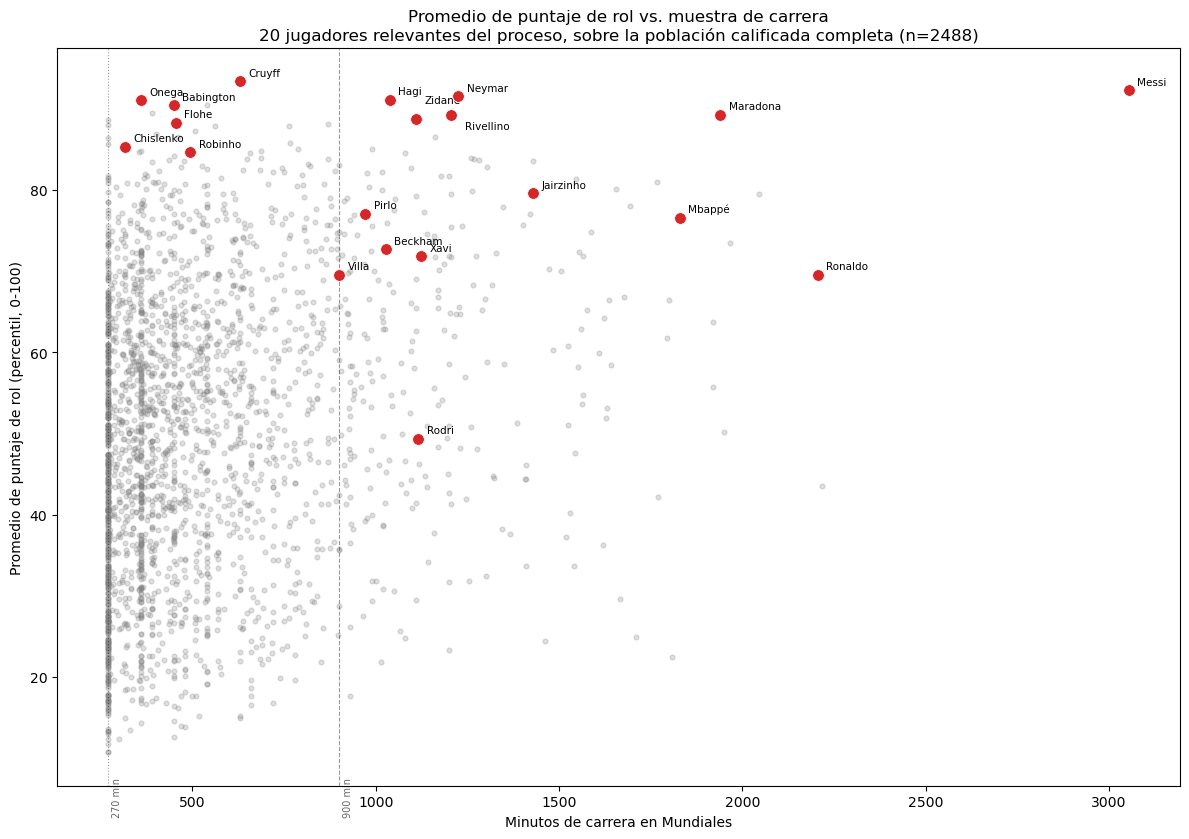

In [11]:
fig, ax = plt.subplots(figsize=(12, 8.5))

ax.scatter(dataset_final["minutesPlayed"], dataset_final["role_score_avg"],
           alpha=0.25, s=12, color="gray", label="Población calificada (n=2488)")

highlighted = dataset_final[dataset_final["name"].isin(process_players)]
ax.scatter(highlighted["minutesPlayed"], highlighted["role_score_avg"],
           color="#d62728", s=70, zorder=5, edgecolors="white", linewidths=0.5)

# Offsets manuales solo para las dos etiquetas que se pisaban (Zidane/Rivellino)
manual_offsets = {"Zidane": (6, 12), "Rivellino": (10, -10)}

for _, row in highlighted.iterrows():
    label = row["name"].split()[-1]
    offset = manual_offsets.get(label, (6, 4))
    ax.annotate(label, (row["minutesPlayed"], row["role_score_avg"]),
                textcoords="offset points", xytext=offset, fontsize=7.5)

ax.axvline(270, color="black", linestyle=":", linewidth=0.8, alpha=0.4)
ax.axvline(900, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
ax.text(280, 3, "270 min", fontsize=7, alpha=0.6, rotation=90)
ax.text(910, 3, "900 min", fontsize=7, alpha=0.6, rotation=90)

ax.set_xlabel("Minutos de carrera en Mundiales")
ax.set_ylabel("Promedio de puntaje de rol (percentil, 0-100)")
ax.set_title("Promedio de puntaje de rol vs. muestra de carrera\n20 jugadores relevantes del proceso, sobre la población calificada completa (n=2488)")

plt.tight_layout()
plt.savefig("../reports/figures/avg_score_vs_minutes_full.png", dpi=150, bbox_inches="tight")
plt.show()

**Pattern in the chart:** among the players near the top of the average
role score, Messi's 3054 minutes dwarf even his closest rival by that
measure. Maradona, the nearest large-sample competitor, has 1940 minutes
across 4 World Cups, already a wide gap. After that it widens further:
Neymar (1225), Hagi (1039), and Cruyff (630) all rank near Messi in
average score with dramatically less playing time.

**Interpretation, reasoned but not provable as a counterfactual:** a
football career typically follows an arc, an early developing stage,
where even talented young players are rarely first-choice starters in a
tournament as selective as a World Cup; a middle "prime" stage, roughly
the mid-to-late twenties, where most of a player's minutes at this level
accumulate; and a later stage of decline, where playing time drops again.
Most players who reach several World Cups concentrate their minutes in
that prime window. Messi's total is too large to be explained by
prime-years minutes alone, it necessarily includes substantial minutes at
both ends of that arc (his first World Cup at 18, his last one two
decades later). Whether his average would have held up if his rivals here
had played as many young and old-age minutes as he did can't be
quantified, that's an unmeasurable counterfactual. But the pattern is
real and grounded in a well-known regularity of football careers, not
invented for this case, and it adds a layer of difficulty to the finding
that the raw average score doesn't show by itself.

---

**Patrón en el gráfico:** entre los jugadores cerca del top del promedio
de puntaje de rol, los 3054 minutos de Messi superan ampliamente incluso
a su rival más cercano en esa medida. Maradona, el competidor de muestra
grande más cercano, tiene 1940 minutos en 4 Mundiales, ya una brecha
amplia. Después se ensancha más: Neymar (1225), Hagi (1039), y Cruyff
(630) quedan todos cerca de Messi en promedio con muchísimos menos
minutos jugados.

**Interpretación, razonada pero no demostrable como contrafactual:** una
carrera futbolística suele seguir un arco, una etapa inicial de
desarrollo, donde incluso jóvenes talentosos rara vez son titulares
indiscutidos en un torneo tan selectivo como un Mundial; una etapa media
de "prime", aproximadamente entre los veinticinco y veintinueve años,
donde se acumula la mayoría de los minutos de un jugador a este nivel; y
una etapa final de declive, donde los minutos vuelven a bajar. La mayoría
de los jugadores que llegan a varios Mundiales concentran sus minutos en
esa ventana de prime. El total de Messi es demasiado grande para
explicarse solo con minutos de su prime, necesariamente incluye minutos
importantes en los dos extremos de ese arco (su primer Mundial a los 18,
el último dos décadas después). Si su promedio se hubiera sostenido en
caso de que sus rivales acá hubieran jugado tantos minutos de juventud y
de veteranía como él, no se puede cuantificar, es un contrafactual
inmedible. Pero el patrón es real y se apoya en una regularidad conocida
de las carreras futbolísticas, no inventada para este caso, y le agrega
una capa de dificultad al hallazgo que el promedio crudo no muestra por
sí solo.

## Chart 2: how rare is reaching the elite ceiling

Distribution of how many roles each of the 2488 qualified players reaches
at the genuine elite threshold (90th percentile), so the ceiling Messi
shares with 7 other players can be read against how the rest of the
population is distributed, not just as an isolated number.

---

## Gráfico 2: qué tan raro es llegar al techo de élite

Distribución de en cuántos roles llega cada uno de los 2488 jugadores
calificados en el umbral real de élite (percentil 90), para que el techo
que Messi comparte con otros 7 jugadores se pueda leer contra cómo se
distribuye el resto de la población, no como un número aislado.

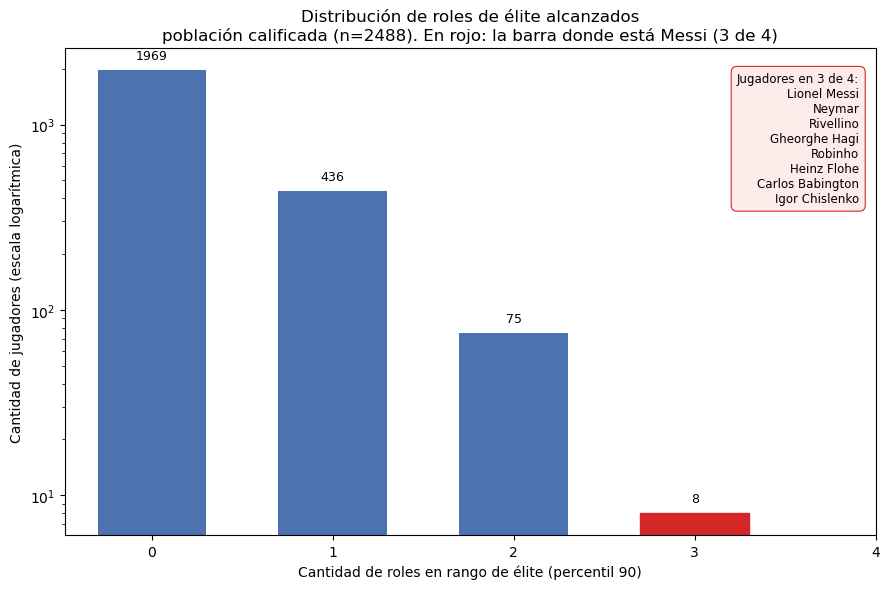

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

counts = dataset_final["n_elite_roles_90"].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color="#4c72b0", width=0.6)

messi_n = dataset_final[dataset_final["name"] == "Lionel Messi"]["n_elite_roles_90"].values[0]
bars[int(messi_n)].set_color("#d62728")

ax.set_yscale("log")

for i, v in zip(counts.index, counts.values):
    ax.text(i, v * 1.15, str(v), ha="center", fontsize=9)

players_at_3 = dataset_final[dataset_final["n_elite_roles_90"] == 3].sort_values(
    "minutesPlayed", ascending=False
)["name"].tolist()
players_at_3_label = "Jugadores en 3 de 4:\n" + "\n".join(players_at_3)

ax.text(
    0.98, 0.95, players_at_3_label,
    transform=ax.transAxes, fontsize=8.5, ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#fdecea", edgecolor="#d62728", linewidth=0.8),
)

ax.set_xlabel("Cantidad de roles en rango de élite (percentil 90)")
ax.set_ylabel("Cantidad de jugadores (escala logarítmica)")
ax.set_title("Distribución de roles de élite alcanzados\npoblación calificada (n=2488). En rojo: la barra donde está Messi (3 de 4)")
ax.set_xticks([0, 1, 2, 3, 4])

plt.tight_layout()
plt.savefig("../reports/figures/elite_role_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 3.1: Messi vs. multi-role standouts and reference players

The 12 players from Phase 6 (4 statistical leaders across the 900-minute
floor, 8 manually added references), plotted against Messi on the same
four axes.

---

## Gráfico 3.1: Messi contra los que destacan en varios roles y las referencias

Los 12 jugadores de la Fase 6 (4 líderes estadísticos con el piso de 900
minutos, 8 referencias agregadas manualmente), graficados contra Messi
sobre los mismos cuatro ejes.

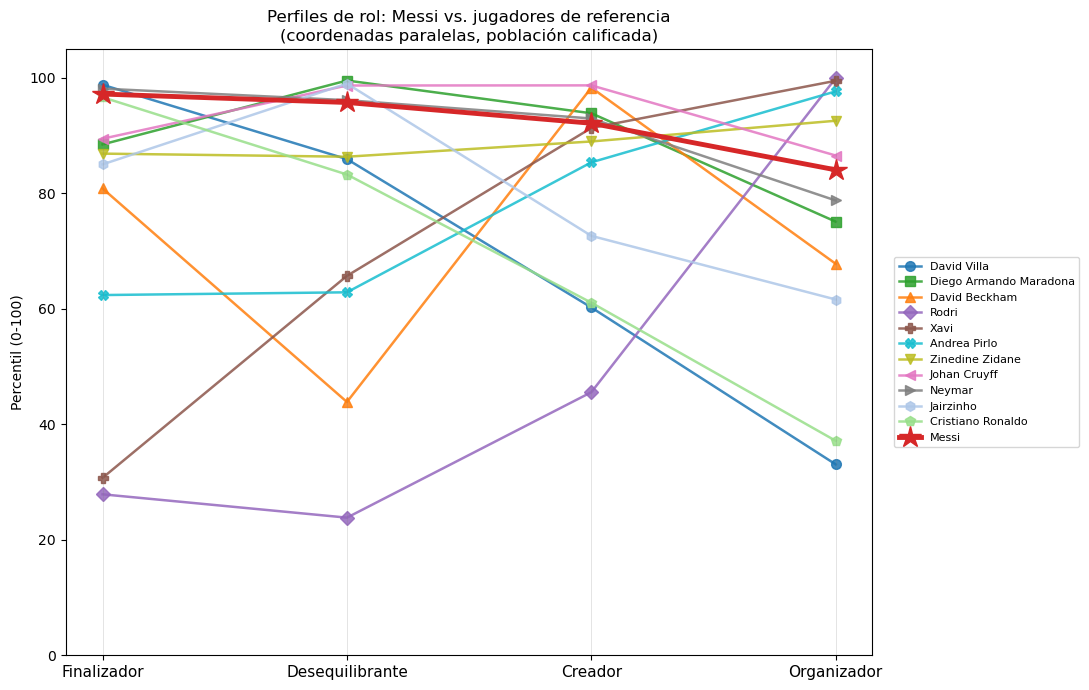

In [21]:
categories = ["Finalizador", "Desequilibrante", "Creador", "Organizador"]
x_positions = list(range(len(categories)))

distinct_colors = [
    "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b",
    "#17becf", "#bcbd22", "#e377c2", "#7f7f7f", "#aec7e8", "#98df8a",
]
markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "h", "p"]

fig, ax = plt.subplots(figsize=(11, 7))

other_players = [p for p in radar_players if p != "Lionel Messi"]

for name, color, marker in zip(other_players, distinct_colors, markers):
    row = dataset_final[dataset_final["name"] == name]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    values = [row["finisher_score"], row["dribbler_score"], row["chance_creator_score"], row["play_organizer_score"]]
    ax.plot(x_positions, values, linewidth=1.8, color=color, marker=marker, markersize=7, label=name, alpha=0.85)

messi_row = dataset_final[dataset_final["name"] == "Lionel Messi"].iloc[0]
messi_values = [messi_row["finisher_score"], messi_row["dribbler_score"],
                 messi_row["chance_creator_score"], messi_row["play_organizer_score"]]
ax.plot(x_positions, messi_values, linewidth=3.5, color="#d62728", marker="*", markersize=16, label="Messi", zorder=5)

for x in x_positions:
    ax.axvline(x, color="gray", linewidth=0.5, alpha=0.3)

ax.set_xticks(x_positions)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 105)
ax.set_ylabel("Percentil (0-100)")
ax.set_title("Perfiles de rol: Messi vs. jugadores de referencia\n(coordenadas paralelas, población calificada)")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/radar_messi_vs_references.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 3.2: Messi vs. the top 5 of each individual role (900+ minutes)

Four small radars, one per role, each showing that role's top 5 players
(900-minute floor, to exclude short-sample peaks like Isco's organizer
lead) against Messi on the same four axes. This shows each specialist's
peak alongside their weaknesses elsewhere, role by role, instead of
compressing everyone into one unreadable chart.

---

## Gráfico 3.2: Messi contra el top 5 de cada rol individual (900+ minutos)

Cuatro radares pequeños, uno por rol, cada uno mostrando el top 5 de ese
rol (piso de 900 minutos, para excluir picos de muestra chica como el
liderazgo de Isco en organizador) contra Messi sobre los mismos cuatro
ejes. Muestra el pico de cada especialista junto a sus debilidades en los
demás roles, rol por rol, en vez de comprimir a todos en un solo gráfico
ilegible.

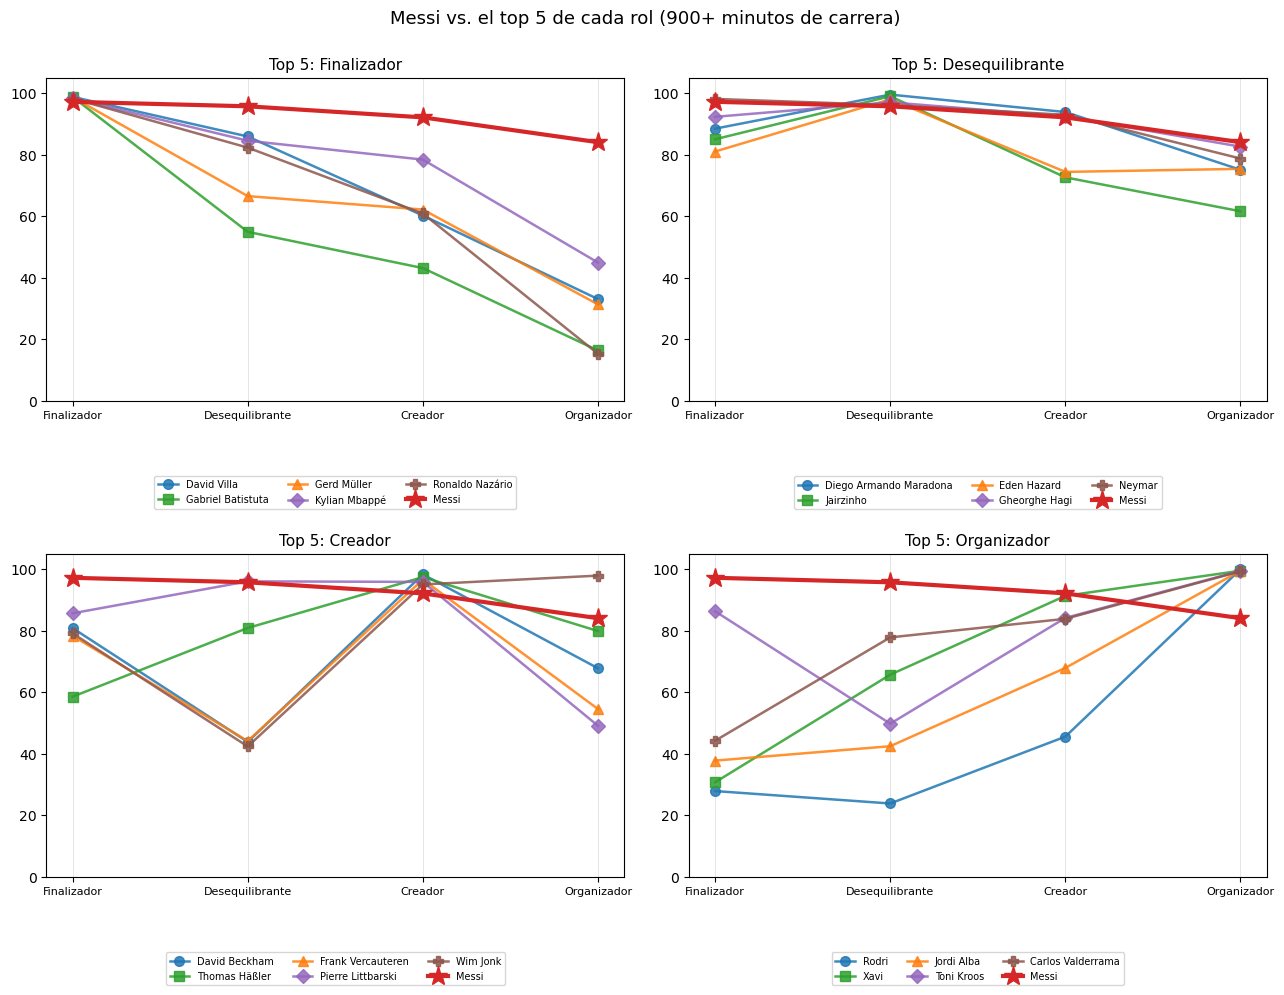

In [22]:
role_labels = {
    "finisher_score": "Finalizador",
    "dribbler_score": "Desequilibrante",
    "chance_creator_score": "Creador",
    "play_organizer_score": "Organizador",
}
distinct_colors_5 = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]
markers_5 = ["o", "s", "^", "D", "P"]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (role_col, role_label) in zip(axes, role_labels.items()):
    top5 = qualified_900.nlargest(5, role_col)

    for (_, row), color, marker in zip(top5.iterrows(), distinct_colors_5, markers_5):
        values = [row["finisher_score"], row["dribbler_score"], row["chance_creator_score"], row["play_organizer_score"]]
        ax.plot(x_positions, values, linewidth=1.8, color=color, marker=marker, markersize=7, label=row["name"], alpha=0.85)

    ax.plot(x_positions, messi_values, linewidth=3, color="#d62728", marker="*", markersize=14, label="Messi", zorder=5)

    for x in x_positions:
        ax.axvline(x, color="gray", linewidth=0.5, alpha=0.3)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, fontsize=8)
    ax.set_ylim(0, 105)
    ax.set_title(f"Top 5: {role_label}", fontsize=11)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), fontsize=7, ncol=3)

plt.suptitle("Messi vs. el top 5 de cada rol (900+ minutos de carrera)", fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig("../reports/figures/radar_top5_by_role.png", dpi=150, bbox_inches="tight")
plt.show()

## Visual synthesis: what the charts show, and where data ends and interpretation begins

**Data pattern, visible directly in Chart 3.2:** the finisher panel shows
the widest gap between Messi and the rest of any of the four role panels.
His competitors there (Villa, Müller, Batistuta, Mbappé, Ronaldo Nazário)
score nearly as high as Messi on the finisher axis (all in the 78-99
range) but collapse sharply on the other three (several drop below 20 on
organizer). Messi's line is the flattest of the four panels' worst case,
dropping from 97 to a floor of 84. The dribbler panel shows a
structurally different pattern: competitors there (Maradona, Jairzinho,
Hazard, Hagi, Neymar) stay much closer to Messi across all four axes,
the gap never opens up the way it does in the finisher panel. Both of
these are direct, visible readings of the data, not interpretation.

**An interpretive note, offered explicitly as opinion, not a finding:**
goals are arguably the hardest and most valued output in football, to
the point that a reliably prolific scorer is often permitted, in practice,
to contribute less elsewhere, defend less, press less, generate less for
teammates, because they finish what others create instead of needing to
create it themselves. Read this way, the finisher panel is the strongest
illustration of the whole project: Messi matches the specialists at the
one thing that most excuses specialization, and still doesn't fall off
anywhere else. This is a value judgment about which football skills
matter most and why, reasonable people can and do disagree with it, and
it's recorded here as the project's opinion layer, not as something the
statistics themselves establish.

---

## Síntesis visual: qué muestran los gráficos, y dónde termina el dato y empieza la interpretación

**Patrón de datos, visible directamente en el Gráfico 3.2:** el panel de
finalizador muestra la brecha más amplia entre Messi y el resto de los
cuatro paneles de rol. Sus competidores ahí (Villa, Müller, Batistuta,
Mbappé, Ronaldo Nazário) puntúan casi tan alto como Messi en el eje de
finalizador (todos entre 78-99) pero se derrumban en los otros tres
(varios bajan de 20 en organizador). La línea de Messi es la más plana en
el peor caso de los cuatro paneles, bajando de 97 a un piso de 84. El
panel de desequilibrante muestra un patrón estructuralmente distinto: los
competidores ahí (Maradona, Jairzinho, Hazard, Hagi, Neymar) se mantienen
mucho más cerca de Messi en los cuatro ejes, la brecha nunca se abre como
en el panel de finalizador. Las dos cosas son lecturas directas y
visibles de los datos, no interpretación.

**Una nota interpretativa, ofrecida explícitamente como opinión, no como
hallazgo:** los goles son posiblemente el resultado más difícil y más
valorado del fútbol, al punto que a un goleador confiablemente prolífico
en la práctica se le suele permitir aportar menos en otras áreas,
defender menos, presionar menos, generar menos para sus compañeros,
porque convierte lo que otros crean en vez de necesitar crearlo él mismo.
Leído así, el panel de finalizador es la ilustración más fuerte de todo
el proyecto: Messi iguala a los especialistas justo en lo único que más
suele excusar la especialización, y aun así no se cae en ningún otro
lado. Esto es un juicio de valor sobre qué habilidades del fútbol
importan más y por qué, personas razonables pueden no estar de acuerdo,
y queda registrado acá como la capa de opinión del proyecto, no como algo
que las estadísticas mismas establezcan.

## Conclusion

Integrated Phases 2-6 into two files: `dataset_final.csv` (2488 players,
72 columns spanning career totals, per-90 rates, the four role scores,
elite-role counts at three thresholds, and the average role score) and
`role_specialists.csv` (12 labeled reference rows for the radar chart).
Verified before exporting, not assumed: `role_metrics` and `role_scores`
share the exact same 2488 player ids, the merge produced no duplicates
and no fully-empty columns, and five key players (Messi, Maradona,
Cristiano, Cruyff, Zidane) carry consistent values from both source files
matching every number already reported in Phases 3-6.

Built four preview visualizations from the final dataset, saved to
`reports/figures/`, as working sketches for the actual Tableau dashboard.
The first, average role score against career minutes, prompted a
career-arc interpretation worth carrying forward: Messi's 3054 minutes
are so far beyond even his closest rival by average score (Maradona,
1940) that they can't be explained by prime-age minutes alone, they
necessarily span both the early and late stages of a career where
playing time is typically scarcer, adding a layer of difficulty to the
finding beyond what the number shows on its own, reasoned from a known
football regularity, not provable as a counterfactual. The second chart
showed exactly how rare the 3-of-4 elite-role ceiling Messi shares with 7
others actually is against the full population. The two parallel-coordinates
charts, contrasting Messi against multi-role standouts and against each
role's individual top 5, surfaced a pattern worth naming explicitly in
the finisher panel: it's the only one of the four where Messi's
specialist competitors match him on their own axis but collapse
everywhere else, while he doesn't. That pattern is a direct reading of
the data. Why it might matter, that scoring is arguably football's
hardest and most excusing skill, is recorded separately as the project's
own interpretation, not smuggled in as a statistical finding.

The full pipeline is now reproducible end to end from raw SofaScore data
to these two files: `01_extraction_coverage` confirms the raw data,
`02_population_build` cleans and aggregates it, `03_role_metrics`
normalizes and assigns it to roles, `04_role_correlations` tests whether
the roles behave as distinct dimensions, `05_multirole_elite_count`
answers the central question through multiple lenses, `06_role_specialists`
prepares the communication layer, and this notebook brings it together
and previews how it will be shown. What's left is building the actual
Tableau dashboard from these files and sketches, and the final
README/documentation pass.

---

## Conclusión

Se integraron las Fases 2-6 en dos archivos: `dataset_final.csv` (2488
jugadores, 72 columnas que abarcan totales de carrera, tasas per 90, los
cuatro puntajes de rol, conteos de élite en tres umbrales, y el promedio
de puntaje de rol) y `role_specialists.csv` (12 filas de referencia
etiquetadas para el radar chart). Verificado antes de exportar, no
asumido: `role_metrics` y `role_scores` comparten exactamente el mismo
conjunto de 2488 ids de jugador, la unión no produjo duplicados ni
columnas completamente vacías, y cinco jugadores clave (Messi, Maradona,
Cristiano, Cruyff, Zidane) llevan valores consistentes de ambos archivos
fuente, coincidiendo con cada número ya reportado en las Fases 3-6.

Se construyeron cuatro visualizaciones previas desde el dataset final,
guardadas en `reports/figures/`, como bocetos de trabajo para el
dashboard real de Tableau. La primera, promedio de puntaje de rol contra
minutos de carrera, motivó una interpretación sobre el arco de una
carrera que vale la pena llevar adelante: los 3054 minutos de Messi están
tan por encima incluso de su rival más cercano por promedio (Maradona,
1940) que no se explican solo con minutos de su prime, necesariamente
abarcan tanto la etapa temprana como la tardía de una carrera, donde los
minutos suelen ser más escasos, agregando una capa de dificultad al
hallazgo más allá de lo que muestra el número por sí solo, razonado desde
una regularidad conocida del fútbol, no demostrable como contrafactual.
El segundo gráfico mostró exactamente qué tan raro es el techo de 3-de-4
roles de élite que Messi comparte con otros 7, contra la población
completa. Los dos gráficos de coordenadas paralelas, contrastando a
Messi contra los que destacan en varios roles y contra el top 5
individual de cada rol, sacaron a la luz un patrón que vale la pena
nombrar de forma explícita en el panel de finalizador: es el único de los
cuatro donde los competidores especialistas de Messi lo igualan en su
propio eje pero se derrumban en todo lo demás, mientras que él no. Ese
patrón es una lectura directa de los datos. Por qué podría importar, que
convertir es posiblemente la habilidad más difícil y más excusable del
fútbol, queda registrado por separado como la interpretación propia del
proyecto, no colado como un hallazgo estadístico.

El pipeline completo ahora es reproducible de punta a punta desde los
datos crudos de SofaScore hasta estos dos archivos: `01_extraction_coverage`
confirma los datos crudos, `02_population_build` los limpia y agrega,
`03_role_metrics` los normaliza y asigna a roles, `04_role_correlations`
prueba si los roles se comportan como dimensiones distintas,
`05_multirole_elite_count` responde la pregunta central con varias
miradas, `06_role_specialists` prepara la capa de comunicación, y este
notebook lo junta todo y previsualiza cómo se va a mostrar. Lo que queda
es construir el dashboard real de Tableau a partir de estos archivos y
bocetos, y la pasada final de README/documentación.